In [1]:
import getpass
import os
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import END, StateGraph,START
from typing import List, TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI

# Set environment variables for API keys
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


_set_env("GEMINI_API_KEY")
_set_env("TAVILY_API_KEY")

# Initialize embeddings and vectorstore
embd = OpenAIEmbeddings()
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

# Load and split documents
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(docs_list)

# Create vectorstore
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=embd,
)
retriever = vectorstore.as_retriever()



USER_AGENT environment variable not set, consider setting it to identify your requests.
/Users/abinashpant/Codes/projects/agents_basesetup/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Use the LLM to classify the query.
llm = ChatGoogleGenerativeAI(
        model='gemini-2.0-flash-exp',
        api_key=os.getenv('GEMINI_API_KEY')
    )

In [4]:
# Define the Graph State
class GraphState(TypedDict):
    question: str
    generation: str
    documents: List[str]


# Define nodes for the graph
def retrieve(state: GraphState):
    """Retrieve documents from the vectorstore."""
    print("---RETRIEVE---")
    question = state["question"]
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def generate(state: GraphState):
    """Generate an answer using the retrieved documents."""
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    prompt = hub.pull("rlm/rag-prompt")
    rag_chain = prompt | llm | StrOutputParser()
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def transform_query(state: GraphState):
    """Transform the query to improve retrieval."""
    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    system = """You are a question re-writer that converts an input question to a better version optimized for retrieval."""
    re_write_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Here is the initial question: \n\n {question} \n Formulate an improved question."),
        ]
    )
    question_rewriter = re_write_prompt | llm | StrOutputParser()
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def web_search(state: GraphState):
    """Perform a web search using the Tavily API."""
    print("---WEB SEARCH---")
    question = state["question"]
    web_search_tool = TavilySearchResults(k=3)
    docs = web_search_tool.invoke({"query": question})
    web_results = "\n".join([d["content"] for d in docs])
    return {"documents": [web_results], "question": question}


# Define edges for the graph
def route_question(state: GraphState):
    """Route the question to either web search or RAG."""
    print("---ROUTE QUESTION---")
    question = state["question"]
    source = "web_search" if "web" in question.lower() else "vectorstore"
    if source == "web_search":
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    else:
        print("---ROUTE QUESTION TO RAG---")
        return "retrieve"


def decide_to_generate(state: GraphState):
    """Decide whether to generate an answer or transform the query."""
    print("---DECIDE TO GENERATE---")
    documents = state["documents"]
    if not documents:
        print("---DECISION: TRANSFORM QUERY---")
        return "transform_query"
    else:
        print("---DECISION: GENERATE---")
        return "generate"




In [5]:
# Compile the graph
workflow = StateGraph(GraphState)

# Add nodes
workflow.add_node("retrieve", retrieve)
workflow.add_node("generate", generate)
workflow.add_node("transform_query", transform_query)
workflow.add_node("web_search", web_search)

# Add edges
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search": "web_search",
        "retrieve": "retrieve",
    },
)
workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "generate")
workflow.add_conditional_edges(
    "generate",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": END,
    },
)
workflow.add_edge("transform_query", "retrieve")

# Compile the workflow
app = workflow.compile()



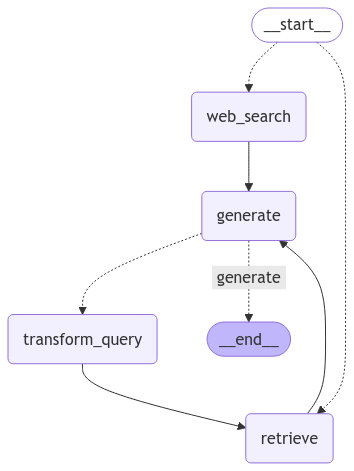

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
# Function to process a question
def process_question(question: str):
    inputs = {"question": question}
    for output in app.stream(inputs):
        for key, value in output.items():
            print(f"Node '{key}':")
            print(value)
        print("====== END OF NODE ======")
        print("\n")

    print("====== FINAL GENERATION ======")
    print(value["generation"])


# Example usage
process_question("What is protein ?")

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---RETRIEVE---
Node 'retrieve':
{'documents': [Document(metadata={'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nSho

/Users/abinashpant/Codes/projects/agents_basesetup/venv/lib/python3.10/site-packages/langsmith/client.py:256: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


---DECIDE TO GENERATE---
---DECISION: GENERATE---
Node 'generate':
{'documents': [Document(metadata={'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory